## Do highly rated books tend to be more expensive?

***Author***: Amadou Sow

***Date***: May 2026


## 1.Library import 

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import networkx as nx
import statsmodels.api as sm
from scipy.stats import f_oneway

## 2 - Directed Acyclic Graph

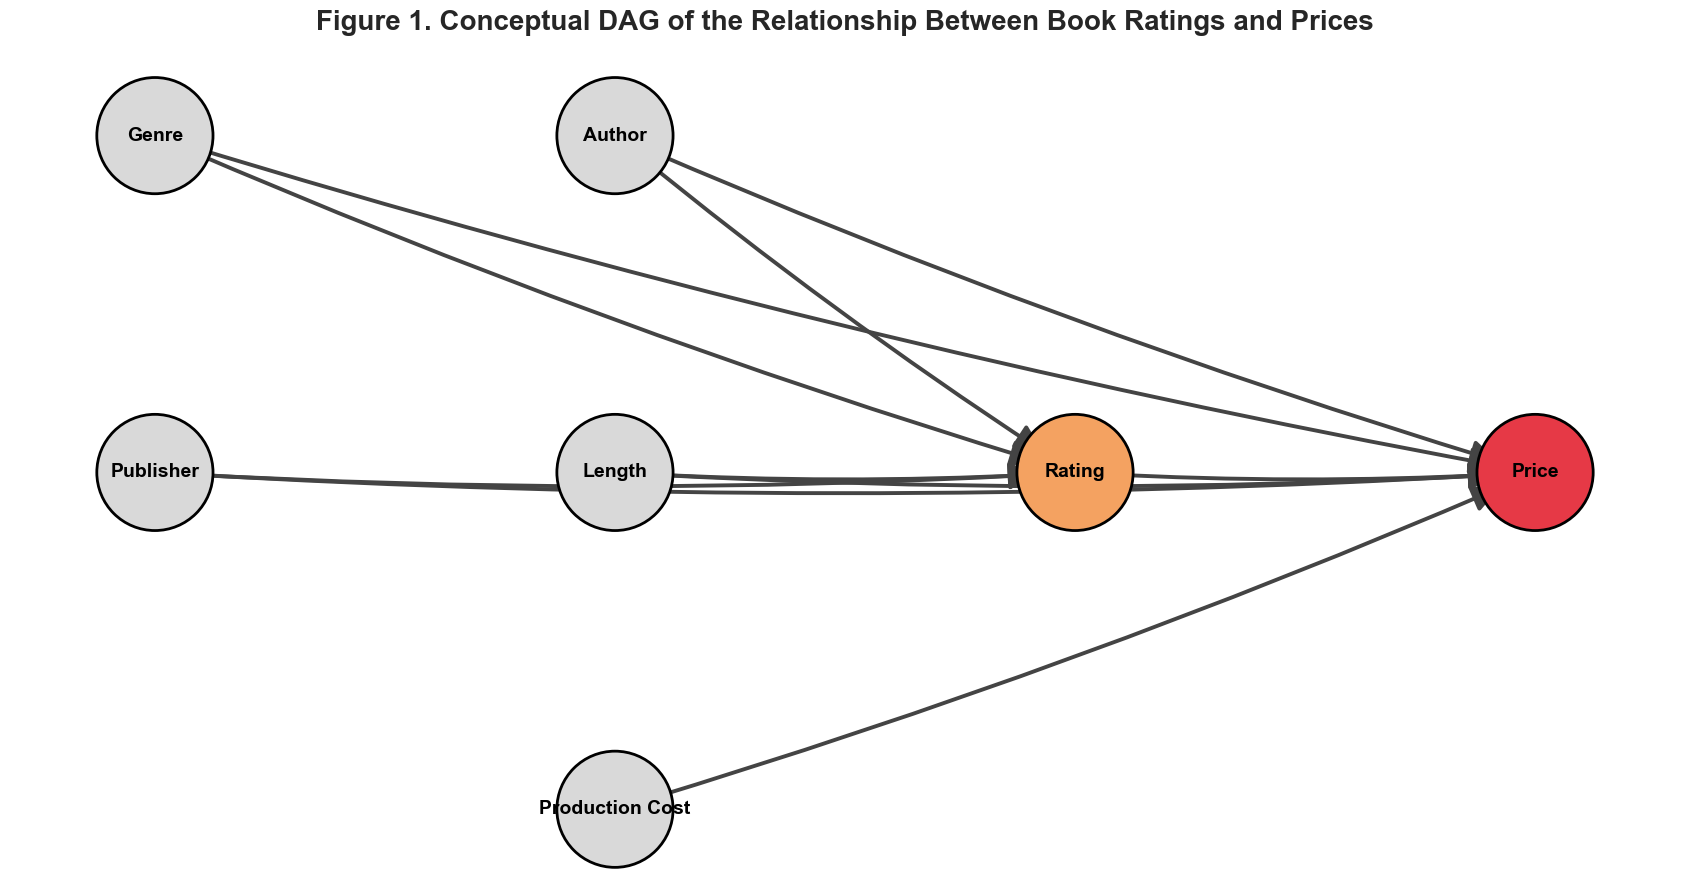

In [77]:
# DAG

G = nx.DiGraph()

# Nodes
nodes = [
    "Genre",
    "Publisher",
    "Author",
    "Length",
    "Production Cost",
    "Rating",
    "Price"
]

G.add_nodes_from(nodes)

# Edges
edges = [

    ("Genre", "Rating"),
    ("Genre", "Price"),

    ("Publisher", "Rating"),
    ("Publisher", "Price"),

    ("Author", "Rating"),
    ("Author", "Price"),

    ("Length", "Rating"),
    ("Length", "Price"),

    ("Production Cost", "Price"),

    ("Rating", "Price")
]

G.add_edges_from(edges)

# NODE POSITIONS

pos = {

    "Genre": (-2, 4),

    "Publisher": (-2, 2),

    "Author": (1, 4),

    "Length": (1, 2),

    "Production Cost": (1, 0),

    "Rating": (4, 2),

    "Price": (7, 2)
}

# NODE COLORS

node_colors = []

for node in G.nodes():

    if node == "Rating":
        node_colors.append("#f4a261")

    elif node == "Price":
        node_colors.append("#e63946")

    else:
        node_colors.append("#d9d9d9")

# Figure

plt.figure(figsize=(17,9))

# Nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_color=node_colors,
    node_size=7000,
    edgecolors="black",
    linewidths=2
)

# Labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=14,
    font_weight="bold"
)

# Edges
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle='-|>',
    arrowsize=40,
    width=2.8,
    edge_color="#444444",
    min_source_margin=20,
    min_target_margin=28,
    connectionstyle="arc3,rad=0.03"
)

# Title
plt.title(
    "Figure 1. Conceptual DAG of the Relationship Between Book Ratings and Prices",
    fontsize=20,
    fontweight="bold",
    pad=25
)

plt.axis("off")

plt.tight_layout()

plt.show()

## 3. Data import 

In [78]:
df = pd.read_csv("databooks.csv")
print(df.head())


                                   Title    Price  Rating
0                   A Light in the Attic  Â£51.77       3
1                     Tipping the Velvet  Â£53.74       1
2                             Soumission  Â£50.10       1
3                          Sharp Objects  Â£47.82       4
4  Sapiens: A Brief History of Humankind  Â£54.23       5


## 4. data description 

In [79]:
# Cleaning the data 
df["Price_clean"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .astype(float)
)

C:\Users\HP GUEST\AppData\Local\Temp\ipykernel_27824\1517785714.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


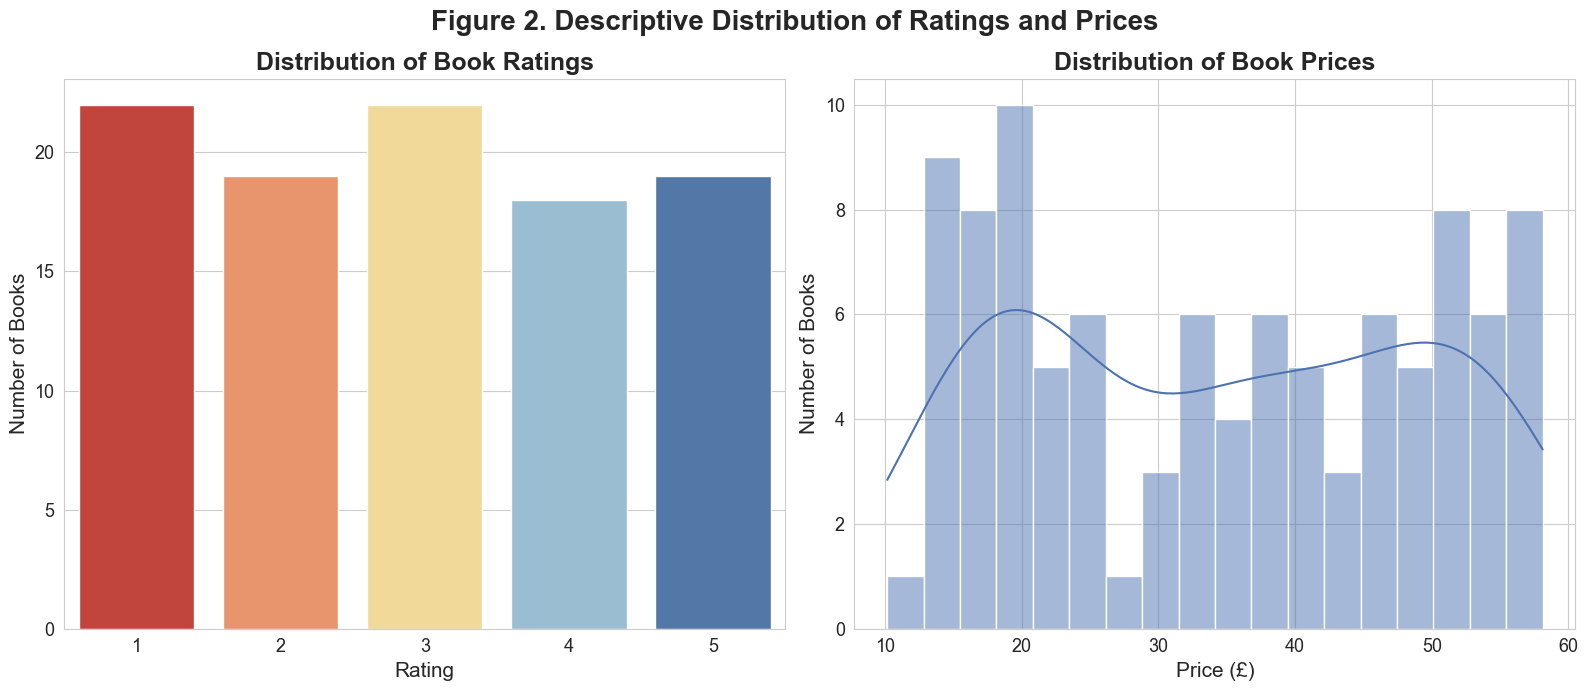

In [80]:

sns.set_style("whitegrid")

# figure with 2 panels
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,7)
)

# GRAPH 1 : Distribution of Ratings

rating_colors = [
    "#d73027",  # 1 star
    "#fc8d59",  # 2 stars
    "#fee08b",  # 3 stars
    "#91bfdb",  # 4 stars
    "#4575b4"   # 5 stars
]

sns.countplot(
    data=df,
    x="Rating",
    palette=rating_colors,
    ax=axes[0]
)

axes[0].set_title(
    "Distribution of Book Ratings",
    fontsize=18,
    fontweight="bold"
)

axes[0].set_xlabel(
    "Rating",
    fontsize=15
)

axes[0].set_ylabel(
    "Number of Books",
    fontsize=15
)

# Axis Size 
axes[0].tick_params(
    axis='both',
    labelsize=13
)


# GRAPH 2 : Distribution of Prices

sns.histplot(
    data=df,
    x="Price_clean",
    bins=18,
    kde=True,
    color="#4c72b0",
    ax=axes[1]
)

axes[1].set_title(
    "Distribution of Book Prices",
    fontsize=18,
    fontweight="bold"
)

axes[1].set_xlabel(
    "Price (£)",
    fontsize=15
)

axes[1].set_ylabel(
    "Number of Books",
    fontsize=15
)

# Axis Size
axes[1].tick_params(
    axis='both',
    labelsize=13
)

# GLOBAL TITLE

fig.suptitle(
    "Figure 2. Descriptive Distribution of Ratings and Prices",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 5. Box Plot 

C:\Users\HP GUEST\AppData\Local\Temp\ipykernel_27824\2602878329.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


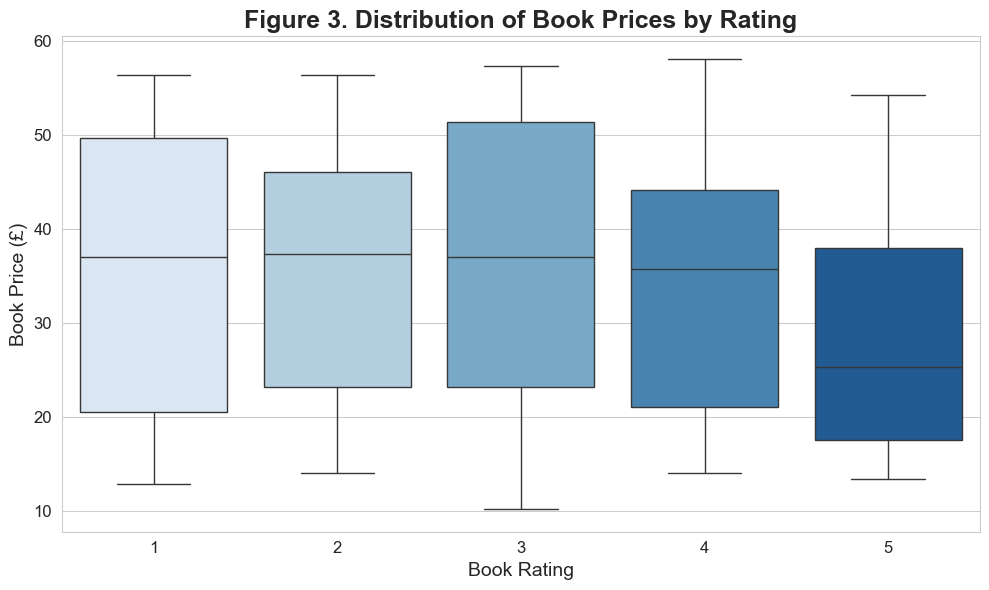

In [81]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="Rating",
    y="Price_clean",
    palette="Blues"
)

plt.title(
    "Figure 3. Distribution of Book Prices by Rating",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Book Rating",
    fontsize=14
)

plt.ylabel(
    "Book Price (£)",
    fontsize=14
)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

##  6. T-Test

In [ ]:
low_rated = df[df["Rating"] <= 2]["Price_clean"]
high_rated = df[df["Rating"] >= 4]["Price_clean"]

# T-test
t_stat, p_value = ttest_ind(
    low_rated,
    high_rated,
    equal_var=False
)

print("T-statistic :", round(t_stat, 4))
print("P-value     :", round(p_value, 4))

T-statistic : 1.1569
P-value     : 0.251
